# Configuring Rendering Lighting

When simulating RGB sensors, how the scene is lit can play a huge role in the
fidelity of the final image. Ultimately, the only thing the camera sees is the
light that reflects off of surfaces and shines on the camera's sensor. If an
environment has no light, the camera sees nothing.

Qualitatively, the nature of the lights can have a huge impact on how the scene
appears (and how humans *perceive* the scene). This tutorial is not about those
subjective issues. You'll need to look elsewhere if you want to get into the
interesting impact that arises from lighting a subject from below versus from
above.

Instead, this tutorial assumes you already know what lighting *effect* you're
trying to achieve and, instead, focuses on the mechanisms available to you
in Drake's sensor simulation. That includes what you can or can't do, typical
traps to avoid, and techniques to quickly converge to your best lighting.

## RenderEngineVtk

Although, both `RenderEngineGl` and `RenderEngineVtk` support user-specified
lights, only `RenderEngineVtk` has sufficient features for this discussion to
be interesting. `RenderEngineVtk` supports physically-based rendering (PBR) a
very effective approximation of the physics of lighting.

When configuring `RenderEngineVtk`'s lighting, there are several major topics
we'll want to address:

  - [Light types](#lights)
  - [Shadows](#shadows)
  - [Illumination models (phong vs PBR)](#illumination-models)
  - [Environment maps](#environment-maps)
      - [Tone mapping and exposure](#tone-mapping)
  - [Total illumination](#total-illumination)
  - [Exposure](#exposure)

Each of these topics get addressed below.

## Necessary Imports


In [1]:
import copy
import json
import math
import os

import cv2
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from pydrake.common import (
    FindResourceOrThrow,
    MemoryFile,
)
from pydrake.common.value import Value
from pydrake.geometry import (
    Box,
    ClippingRange,
    ColorRenderCamera,
    EnvironmentMap,
    EquirectangularMap,
    FramePoseVector,
    GeometryFrame,
    GeometryId,
    GeometryInstance,
    InMemoryMesh,
    IllustrationProperties,
    LightParameter,
    MakeRenderEngineVtk,
    Mesh,
    Meshcat,
    MeshcatVisualizer,
    PerceptionProperties,
    QueryObject,
    RenderCameraCore,
    RenderEngineVtkParams,
    Rgba,
    SceneGraph,
    Sphere,
    StartMeshcat,
)
from pydrake.math import RigidTransform, RotationMatrix
from pydrake.multibody.parsing import PackageMap
from pydrake.systems.framework import DiagramBuilder, LeafSystem
from pydrake.systems.sensors import (
    CameraInfo,
    ImageRgba8U,
)

We'll also start a meshcat instance here. It is typical to do this once at the
beginning of the notebook, and use the same instance throughout.

We're going to use a feature of the meshcat visualizer that will allow us to
position the render cameras by manipulating the view in the visualizer. In
order for this to work, you must open the _modified_ url which will print out
after executing the next block.

In [3]:
meshcat = StartMeshcat()
print(f"The URL to enable camera tracking: {meshcat.web_url()}/?tracked_camera=on")

INFO:drake:Meshcat listening for connections at http://localhost:7000


The URL to enable camera tracking: http://localhost:7000/?tracked_camera=on


Once meshcat is up and connected, this block will check to make sure that camera
tracking is enabled.

In [6]:
if meshcat.GetTrackedCameraPose() is None:
   raise RuntimeError(
      f"Make sure you open the URL: {meshcat.web_url()}/?tracked_camera=on")
print("Camera tracking enabled!")


Camera tracking enabled!


## Building some experiment infrastructure

Before we get going, we're going to build some utilities to help explore rendering.
`RenderEngine`s get configured upon construction. As we explore the effect of
configuration parameters, we're going to enter a loop of adding render engine
instances, rendering, removing engines, and repeating. So, we'll write some
utility classes to facilitate this.

<a id="meshcat-camera-control"></a>
### Controlling the camera from meshcat

Scene lighting is something that should be explored. This tutorial will allow
you to edit `RenderEngine` parameters and re-render, but that's only a part of
the exploration. You also need to be able to conveniently move the camera and
look at the scene from different angles.

This controller will connect to your in-browser meshcat session and access the
browser's camera pose (assuming you've used the right URL -- see above). The
pose of the render camera(s) will match that of meshcat camera.

The browser window and render window will probably have different aspect ratios,
so the images won't match exactly. But efforts have been made so that,
otherwise, the cameras have the same intrinsics and extrinsics.

Note: the lit appearance of the scene _will_ look different between the rendered
images in this tutorial and the visualizer window. The properties we'll be
configuring in this tutorial have no bearing on visualization. It uses its own
lighting model with its own pre-configured lights. So, don't be worried if the
lighting looks obviously different. It's expected.

In [7]:
class CameraController(LeafSystem):
    def __init__(self, scene_graph, meshcat):
        """The single output port provides a RigidTransform defining the
        pose of the camera body in the world frame: X_WC. The value is defined
        by polling the given Meshcat instance. If the meshcat url includes the
        argument `tracked_camera=on` we'll get the pose of the visualizer's
        camera. Otherwise, we simply return some generic camera position.
        """
        LeafSystem.__init__(self)
        self._meshcat = meshcat
        self._source_id = scene_graph.RegisterSource("camera_controller")
        self._frame_id = scene_graph.RegisterFrame(
            source_id=self._source_id, frame=GeometryFrame("camera"))
        output_cls = Value[FramePoseVector]
        self.DeclareAbstractOutputPort("camera_pose",
                                       lambda: output_cls(),
                                       self.CalcPose)
        # Looking down from above.
        self._default_X_WC = RigidTransform(
            R=RotationMatrix.MakeXRotation(math.pi), p=[0, 0, 5])

    def frame_id(self):
        return self._frame_id

    def source_id(self):
        return self._source_id

    def set_camera_pose(self, pose_in_world=None):
        """Sets the override camera pose."""
        self._X_WC = pose_in_world

    def CalcPose(self, context, pose_vector):
        X_WC = self._X_WC
        if X_WC is None:
            X_WC = self._meshcat.GetTrackedCameraPose()
            if X_WC is None:
                X_WC = self._default_X_WC
        poses = FramePoseVector()
        poses.set_value(id=self._frame_id, value=X_WC)
        pose_vector.set_value(poses)


### Rendering infrastructure

We'll be creating a large number of renderings to explore the effect of the
various configuration parameters. `RenderEngine`s can only be configured at
construction. So, that means, to explore, we'll be repeatedly creating and
destroying `RenderEngine` instances. That is only a property of this tutorial.
In normal usage, we'd create a `RenderEngine` once and then render many images
in the course of a simulation. But exploring `RenderEngine` will require a
unique framework. So, we'll create a class that will facilitate this unique
pedagogical task.

In [8]:
class RenderComparator:
    """Configures a diagram that can produce render comparisons between
    multiple engines. The camera poses will be driven by a provided Meshcat
    instance. Each time the rendering is made, the camera pose is pulled from
    `meshcat`.
    """
    def __init__(self, meshcat):
        self._meshcat = meshcat
        builder = DiagramBuilder()
        self._scene_graph = builder.AddSystem(SceneGraph())
        # Note: we'll be changing render engines a lot. So, rather than declare
        # them in SceneGraph's model, we'll simply wait and add them to the
        # context.
        self._source_id = self._scene_graph.RegisterSource("main")

        MeshcatVisualizer.AddToBuilder(builder, self._scene_graph,
                                       self._meshcat)

        self._cam_controller = builder.AddSystem(
            CameraController(self._scene_graph, self._meshcat))
        builder.Connect(self._cam_controller.GetOutputPort("camera_pose"),
                        self._scene_graph.get_source_pose_port(
                            self._cam_controller.source_id()))

        builder.ExportOutput(self._scene_graph.get_query_output_port(),
                            "query_object")

        self._diagram = builder.Build()
        self._context = self._diagram.CreateDefaultContext()
        # Make sure MeshVisualizer publishes content to meshcat.
        self._diagram.ForcedPublish(self._context)

        self._sg_context = self._scene_graph.GetMyContextFromRoot(self._context)

        self._cameras = []

        # The contents of sphere.gltf -- we'll use it to create variations of a
        # PBR sphere.
        self._ball_count = 0
        self._gltf_supporting_files = {"sphere.bin", FindResourceOrThrow(
                "drake/tutorials/resources/sphere.bin")}
        gltf_path = FindResourceOrThrow(
                "drake/tutorials/resources/sphere.gltf")
        with open(gltf_path) as f:
            self._ball_contents = json.load(f)

    @staticmethod
    def _make_camera(renderer_name):
        """Makes a camera referencing the given `renderer_name`."""
         # This matches the default Meshcat vertical field of view.
        fov_y = 75 / 180 * math.pi
        core = RenderCameraCore(
            renderer_name=renderer_name,
            intrinsics=CameraInfo(width=1024, height=768, fov_y=fov_y),
            clipping=ClippingRange(0.1, 100.0),
            X_BS=RigidTransform())
        return ColorRenderCamera(core=core)

    def pose_camera_once(self,
                         camera_in_world,
                         target_in_world=np.array((0, 0, 0)),
                         up_in_world=np.array((0, 0, 1))):
        """Computes a pose for the camera located at `camera_in_world` (p_WC),
        looking at `target_in_world` (p_WT) with the camera's up direction as
        close to `up_in_world` (up_W) as possible. Passes it to
        set_override_camera_pose(), so this pose will only be valid for the
        next invocation of render().

        The camera looks in the v_CT_W direction. v_CT should not point in the
        same direction as up_W.
        """
        p_WC = np.array(camera_in_world)
        p_WT = np.array(target_in_world)
        up_W = np.array(up_in_world)

        def normalized(v):
            return v / np.linalg.norm(v)

        Cz_W = normalized(p_WT - p_WC)
        # Note: -Cy points goes up in the image.
        Cx_W = normalized(np.cross(-up_W, Cz_W))
        Cy_W = normalized(np.cross(Cz_W, Cx_W))

        X_WC = RigidTransform(RotationMatrix(
                                  R=np.column_stack((Cx_W, Cy_W, Cz_W))),
                              p_WC)
        self.set_override_camera_pose(X_WC)

    def set_override_camera_pose(self, pose_in_world):
        self._cam_controller.set_camera_pose(pose_in_world)

    def visualize(self):
        """Make sure MeshVisualizer publishes content to meshcat. This should be
        called after adding geometry to the scene.
        """
        self._diagram.ForcedPublish(self._context)

    @staticmethod
    def _assign_materials(geometry, diffuse_rgba):
        def set_diffuse_maybe(props):
            if diffuse_rgba is not None:
                props.AddProperty("phong", "diffuse", diffuse_rgba)

        illustration = geometry.mutable_illustration_properties()
        if illustration is None:
            illustration = IllustrationProperties()
            set_diffuse_maybe(illustration)
            geometry.set_illustration_properties(illustration)
        else:
            illustration.UpdateProperty("phong", "diffuse", diffuse_rgba)

        perception = geometry.mutable_perception_properties()
        if perception is None:
            perception = PerceptionProperties()
            set_diffuse_maybe(perception)
            geometry.set_perception_properties(perception)
        else:
            perception.UpdateProperty("phong", "diffuse", diffuse_rgba)

    def add_ground(self):
        """Adds a grey ground."""
        ground = GeometryInstance(X_PG=RigidTransform([0, 0, -0.5]),
                                  shape=Box(20, 20, 1), name="ground")
        self._add_geometry(ground, Rgba(0.4, 0.4, 0.4))

    def _get_sphere_shape(self, pbr_material: dict):
        """Returns a Mesh shape derived from sphere.gltf whose pbr materials is
        updated to reflect the material definition in `pbr_material`."""
        gltf_json = copy.deepcopy(self._ball_contents)
        gltf_json["materials"][0]["pbrMetallicRoughness"] = (
            gltf_json["materials"][0]["pbrMetallicRoughness"] | pbr_material)
        mesh_file = MemoryFile(json.dumps(gltf_json), ".gltf", "sphere.gltf")
        mesh_data = InMemoryMesh(mesh_file=mesh_file,
                                 supporting_files={"sphere.bin": FindResourceOrThrow(
                "drake/tutorials/resources/sphere.bin")})
        return Mesh(mesh_data=mesh_data)

    def add_ball(self, pbr_material={}, position=[0, 0, 1]):
        """Add a "white" ball so we can observe various lighting effects on it.
        If `pbr_material` is None, the ball is a Sphere primitive with Phong
        materials. Otherwise, the pbr_material is applied to the sphere.gltf
        file.

        The ball (sphere with radius = 1) is placed at position, p_WB.
        """
        if len(pbr_material) == 0:
            shape = Sphere(1)
            diffuse = Rgba(0.8, 0.8, 0.8)
        else:
            shape = self._get_sphere_shape(pbr_material)
            # When reading the gltf, we don't want to assign a diffuse property.
            diffuse = None
        ball = GeometryInstance(X_PG=RigidTransform(position),
                                shape=shape, name=f"ball{self._ball_count}")
        self._ball_count += 1
        self._add_geometry(ball, diffuse)

    def _add_geometry(self, geometry, diffuse_color = Rgba(1,1,1)):
        self._assign_materials(geometry, diffuse_color)
        self._scene_graph.RegisterGeometry(
            context=self._sg_context,
            source_id=self._source_id,
            frame_id=self._scene_graph.world_frame_id(),
            geometry=geometry)

    def set_render_engines(self, renderer_specs):
        """Clears all render engines from the diagram, adding the engines
        implied by the `renderer_specs` (see RenderEngineSpecs below).
        """
        for camera in self._cameras:
            self._scene_graph.RemoveRenderer(self._sg_context,
                                             camera.core().renderer_name())
        assert self._scene_graph.RendererCount(self._sg_context) == 0
        self._cameras.clear()

        for renderer in renderer_specs:
            self._scene_graph.AddRenderer(
                context=self._sg_context, name=renderer.label,
                renderer=MakeRenderEngineVtk(
                    RenderEngineVtkParams(**renderer.params)))
            self._cameras.append(self._make_camera(renderer.label))

    def render(self):
        """Renders an image for each of the """
        # Bumping the time dirties the dependency tree; CameraController will
        # query for a new camera pose.
        self._context.SetTime(self._context.get_time() + 1)
        query_object = self._diagram.GetOutputPort("query_object").Eval(
            self._context)

        MAX_COLS = 2
        if len(self._cameras) <= MAX_COLS:
           num_cols = len(self._cameras)
           num_rows = 1
        else:
           num_cols = MAX_COLS
           num_rows = int(np.ceil(len(self._cameras) / MAX_COLS))
        width = 7 * num_cols
        height = 5 * num_rows
        fig, ax = plt.subplots(num_rows, num_cols, figsize=(width, height),
                               squeeze=False)
        fig.set_facecolor('white')
        ax = ax.reshape(-1, )
        fig.subplots_adjust(hspace=0.1, left=0.05, right=0.95)

        images = []
        for i, camera in enumerate(self._cameras):
            image = query_object.RenderColorImage(
                camera=camera, parent_frame=self._cam_controller.frame_id(),
                X_PC=RigidTransform())
            ax[i].imshow(image.data)
            ax[i].set_title(camera.core().renderer_name())
            ax[i].set_axis_off()
        for i in range(len(self._cameras), len(ax)):
            ax[i].set_axis_off()
        plt.pause(0.5)

        # Clear any hard-coded camera pose.
        self.set_override_camera_pose(None)


class RenderEngineSpec:
    def __init__(self, label: str, params: dict):
        """Specification for a render engine.
        `label` will be used as the renderer name and the image label.
        `params` is a dictionary that can be used as:
            `RenderEngineVtkParams(**spec).
        """
        self.label = label
        self.params = params

## The first rendering

Let's test the infrastructure. We'll see if we can render a simple image.

### Set up the render framework

We'll create a scene graph, populate it, and configure a single `RenderEngine`
instance using all default parameters.

In [103]:
comparator = RenderComparator(meshcat)

# Add some geometry to the scene.
comparator.add_ground()
comparator.add_ball()

# Make sure we push the geometry to the meshcat browser session.
comparator.visualize()

# Configure a single, default render engine.
default_params = {}
comparator.set_render_engines([RenderEngineSpec("Test Image", default_params)])

# The *next* invocation of render will use *this* pose. Subsequent invocations
# will pull the pose from meshcat.
# Look at the ball and ground from above.
comparator.pose_camera_once(camera_in_world=[0, 0, 5],
                            target_in_world=[0, 0, 0],
                            up_in_world=[0, 1, 0])


### The first rendering

In the meshcat visualizer, you should now see the white sphere on a grey
plane (well, large, flat box). Evaluating the next block should _render_ an
image of the same scene and display that image below the code block.

The initial view is comes from calling `comparator.set_override_camera_pose()`.
However, the act of calling `comparator.render()` clears the override pose.
Subsequent calls to `comparator.render()` will draw the camera pose from the
meshcat visualizer's camera's pose. Thus, subsequent render images will mirror
that of the visualizer.

Try changing the view in your meshcat session and re-evaluating the next block.
Confirm that the render perspective changes with the visualizer's view. If not,
confirm the block above, testing the camera feedback, prints out "Camera
tracking enabled!"

Practice manipulating the view. You'll probably be doing that a fair amount
during the course of this tutorial.

Remember, the lighting in the *first* rendered image will _not_ match the
lighting in the meshcat window.


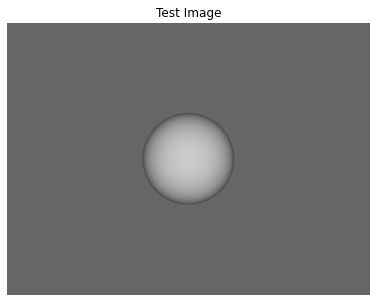

In [104]:
comparator.render()

And with that, we're ready to explore.

<a id="lights"></a>
## Lights

You can think of virtual lights as objects that emit light energy in rays. The
direction of the rays plays a significant role in how the objects in your scene
get illuminated (see below). The various light types basically vary in the
definition of those light rays.

Drake supports three kinds of lights: point, spot, and directional.

  - __Point light__: This is essentially an idealized light bulb. It has zero radius
    so all light rays emanate from a single point. The rays are emitted in all
    directions. Defining the light's `position` determines the emitted light
    rays' origin and directions.
  - __Spot light__: This is a point light with an opaque, conical light shade on it.
    Like a point light, it emits all light from a single point. However, a
    directed cone limits the directions that rays are emitted. The cone has its
    apex at the light `position` and the cone is rotated so its central axis
    is aligned with the light's `direction` vector (such the cone's radius
    expands in `direction`). Finally, the `cone_angle` controls how narrow the
    spot light's beam is. The angle (in degrees) specifies the _half_ angle of
    the cone's span, or the angle between the cone's central axis and the
    boundary of the cone.
  - __Directional light__: This can be thought of a point light that is infinitely
    far away, or idealized sunlight; all emitted light rays are parallel. As
    such, the directional light has no meaningful value for `position`, but its
    `direction` value defines the direction of the emitted light rays.

<div style="text-align: center">
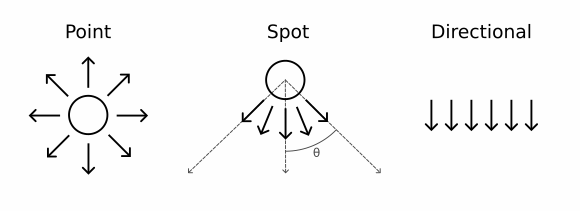
</div>

### Computing diffuse illumination

Light interacts with matter in various ways. While the physics is fascinating
and intricate, and rendering technology typically focuses on the _effects_ and
creates algorithms that approximate many of the observable effects. The names
you might see in this regard are such things as: "diffuse", "specular",
"ambient", "reflection", "refraction", "diffraction", etc., This tutorial won't
necessarily discuss all supported phenomenon. Instead, it will touch (and
possibly elaborate) on those lighting effects that are most relevant to exploring
the rendering configuration.

#### Diffuse lighting

This is the property that we think of when we think of how brightly lit a
surface is. Diffuse reflection is the amount of _observable_ light energy that
reflects off a surface point towards the camera. The _color_ of that light is
a function of the light and surface colors. Its _intensity_ is purely a function
of the orientation of the surface at the point and the direction toward the
light, or the relationship between surface _normal_ and light ray direction. The
direction toward the camera is immaterial.

For a scene with a flat plane, we can see the different diffuse lighting effects
that the three lights have. We'll render a flat plane with three different lights:
a point light 5 meters above the plane, and a spot light 5 meters above the
plane, shining straight down, and a directional light shining directly down on
the plane.

In [105]:
# Three render engines with three different lights. We express the position and
# direction of the lights in the *world* frame; the lights will *not* move with
# the camera.

def make_config(custom_light_params):
    # We'll mix in custom light parameters with these default parameters. Not
    # all parameters will have effect on all light types.
    light = LightParameter(**({"frame": "world",
                               "position": [0, 0, 5],
                               "cone_angle": 50,
                               "direction": [0, 0, -1]
                              } | custom_light_params))
    return {"lights": [light]}

comparator.set_render_engines([
    RenderEngineSpec("Point Light", make_config({"type": "point"})),
    RenderEngineSpec("Spot Light", make_config({"type": "spot"})),
    RenderEngineSpec("Directional Light", make_config({"type": "directional"})),
    ])

# Pick a view above the ground, but not straight down.
comparator.pose_camera_once(camera_in_world=[0, -1, 10])

Don't forget, repeated executions will
[render from your meshcat camera perspective](#meshcat-camera-control).

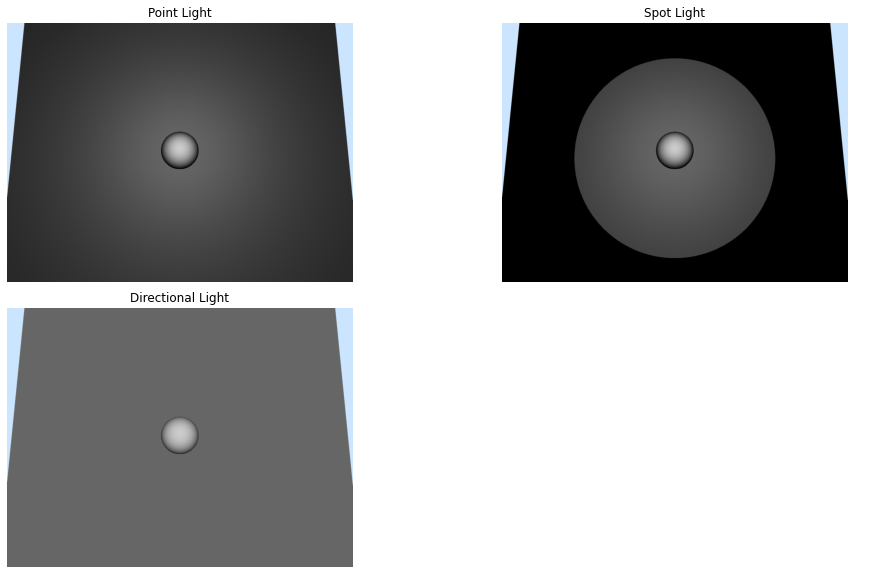

In [106]:
comparator.render()

The difference in the lighting should be apparent. The point light shows a bright
spot directly underneath the light. The ground plane becomes less illuminated as
we move away from that hotspot as the angular deviation between the ground plane
normal and the direction to the point light increases. The spot light illumination
is the same as the point light, but there's a limit to how widely the rays are
cast. The lit circle on the ground illustrates the intersection of the spot
light's illumination cone with the ground. Finally, the ground is uniformly
illuminated with the directional light. The direction of light rays is constant
everywhere in space, and the visible surface of the ground is likewise constant.
So, the level of illumination remains constant.

You can try changing the direction of the directional light and see that the
ground becomes darker and darker as the directional light moves from shining
straight down on the ground to shining horizontally, across the surface.

### Combining lights

A scene can include multiple lights. Sometimes, it is necessary to use multiple
lights to create the final effect of real-world lighting. For `RenderEngineVtk`
you can declare as many lights as you like, although more lights mean greater
computational cost.

In [107]:
# Add several arbitrary light; each with an arbitrarily different color do better
# distinguish the lights.

comparator.set_render_engines([
    RenderEngineSpec(
        "Multiple Lights",
        {"lights": [LightParameter(type="point",
                                   frame="world",
                                   color=Rgba(1, 0, 0),
                                   position=[-2,-2, 1]),
                    LightParameter(type="point",
                                   frame="world",
                                   color=Rgba(0, 1, 0),
                                   position=[-2, 2, 1]),
                    LightParameter(type="point",
                                   frame="world",
                                   color=Rgba(0, 0, 1),
                                   position=[2, 2, 1]),
                    LightParameter(type="point",
                                   frame="world",
                                   position=[2, -2, 1]),
                    LightParameter(type="spot",
                                   frame="world",
                                   color=Rgba(0, 0.8, 0.8),
                                   # Note: the direction vector doesn't have to
                                   # be unit length.
                                   direction=np.array((-1, 0, -1)),
                                   position=[3, 0, 3],
                                   cone_angle=35)
                                   ]}),
    ])

# Pick a view above the ground, but not straight down.
comparator.pose_camera_once(camera_in_world=[0, -1, 10])

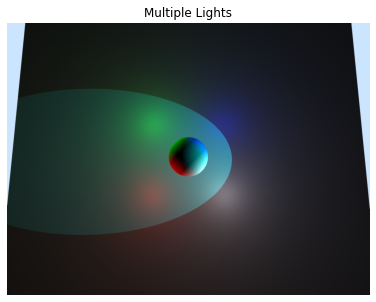

In [108]:
comparator.render()

#### The default light

If no lights are specified, there is a single directional light affixed to the
camera. That is why the ball always looks the same, regardless of how we look at
it. The light is always shining straight ahead from the camera. However, the
ground plane gets darker and darker as we move the camera to look across the
ground plane. You can observe this default light in the initial rendering test
image.

<a id="shadows"></a>
## Shadows

The previous renderings have not included shadows. The only thing that determined
a surface's illumination was the relationship between surface direction and light
direction. In the real world, light can be _occluded_. Physical objects block
the light, casting shadows on surfaces that would otherwise have been lit. In
rendering, we don't get occlusion for free. We create shadows through a variety
of approximations. The spot light's light cone is our first example. In the real
world, a spot light's cone is defined by a can that blocks emitted light. The
virtual spot light is simply modeled as a cone of light directly. However, this
simplified cone model while sufficient for creating a _pool_ of light, is
insufficient for shadows.

There are multiple techniques to detect occlusion. `RenderEngineVtk` uses a
technique called "shadow maps". Shadow maps are an encoding of surfaces that are
visible *to the light source*. Any surface that is visible gets illuminated.
Surfaces that are not visible are in shadow. A shadow map is a texture map
(hence the name), where every pixel contains a value storing the distance of
the closest surface in the direction of the pixel. These distance measurements
are reconciled at rendering time to determine if a surface is in shadow or not.
As a texture map, there are a couple implications:

1. If we encode "what is visible to a light" as a 2D image, we are limited in
   the nature of what can cast shadows (if we can't represent it in an image, we 
   can't cast shadows).
2. The *resolution* of the texture map will affect the appearance of the
   shadows. Essentially, it comes down to the question of how big is a shadow
   map pixel when applied to the real world.

Let's explore these phenomena. But first, let's make sure shadows work.

In [109]:
# One renderer casts shadows, one doesn't. Otherwise identical.

def make_config(custom_config):
    config = {"lights": [LightParameter(type="spot",
                                        frame="world",
                                        position=[0, 0, 5],
                                        cone_angle=50,
                                        direction=[0, 0, -1])]}
    return config | custom_config

comparator.set_render_engines([
    RenderEngineSpec("With Shadows", make_config({"cast_shadows": True})),
    RenderEngineSpec("No Shadows", make_config({"cast_shadows": False}))])

comparator.pose_camera_once(camera_in_world=[0, -3, 3])

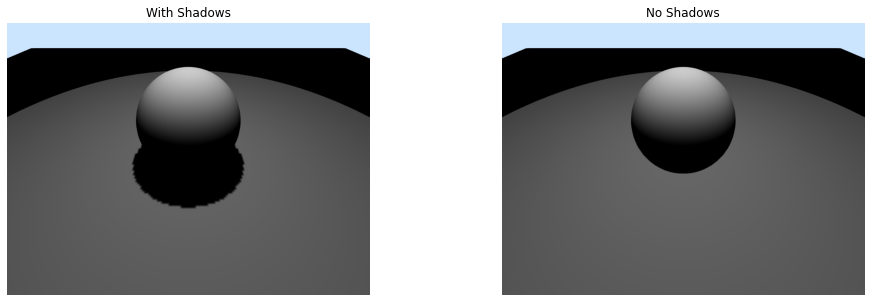

In [110]:
comparator.render()

You should clearly see that the ball casts a shadow on the ground plane in the
image on the left. The image on the right is a repeat from before, but has
*explicitly* disabled shadow casting. If you see the shadow, you can proceed
with the next steps to see how the various settings control the shadow
appearance.

(Keen observers will no doubt notice the pixely edge of the shadow. That topic
is explored below in the "Shadow resolution" section.)


### What lights can cast shadows?

As indicated before, in our implementation *point* lights do not cast shadows.
However, spot and directional lights will cast shadows.

In this case, we've moved the point and spot lights *lower* -- closer to the
ball. The parallel light rays of the directional light will create a different
shadow than the diverging rays of the spot light.

In [111]:
# Each renderer is configured to cast shadows. We've r

# The properties common to all declared lights (some values may
# be ignored -- e.g., cone_angle for point lights).
def make_config(custom_light_params):
   light = LightParameter(**({"frame": "world",
                              "position": [0, 0, 3],
                              "direction": [0, 0, -1],
                              "cone_angle": 50} |
                             custom_light_params))
   return {"lights": [light], "cast_shadows": True}

comparator.set_render_engines([
    RenderEngineSpec("Point Light", make_config({"type": "point"})),
    RenderEngineSpec("Spot Light", make_config({"type": "spot"})),
    RenderEngineSpec("Directional Light", make_config({"type": "directional"})),
    ])

# Pick a view above the ground, but not straight down.
comparator.pose_camera_once(camera_in_world=[0, -2.5, 3.5])

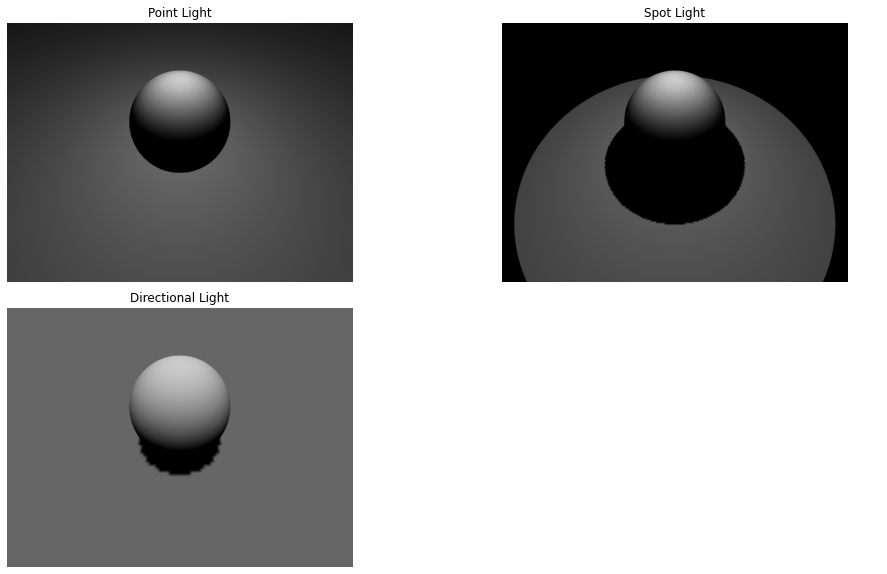

In [112]:
comparator.render()

As promised, the point light casts no shadow on the ground plane. Declaring
`cast_shadows = True` is not an error for point lights; the value simply has no
effect. Conversely, the spot and directional lights both cast shadows, there are
some obvious differences between the shadows.

- The shadow cast from the directional light is smaller than that of the spot
  light Not only that, it even appears smaller than the ball.
   - The directional shadow *is* definitely smaller than the point light shadow.
     Because the spot light's light rays diverge, the shadow will be larger than
     the object casting it. This is illustrated in the figure below in the
     shadow map resolution section.
   - However, the directional shadow is *not* smaller than the ball itself. This
     is an optical illusion due to perspective. The ball's shadow is, in fact,
     the same size as the ball itself. But the shadow is farther from the camera
     than the ball itself. And in perspective, the closer something is, the
     larger it appears.
- The spot light's shadow has a much smoother edge than the directional light.
  The directional light's shadow has a clearly pixelated edge. This is due to
  shadow map resolution (see below).

As a side note, the illuminated surface of the ball looks quite different when
contrasting the directionally-lit ball with that lit with the point or spot
light. We moved the point and spot lights *closer* to the ball. So, the
diverging directions of the light rays has a more significant impact. As
point/spot lights move farther from the illumination target, they asymptotically
approach the behavior of a directional light.

#### Spot light limitations

While spot lights can cast shadows, they can only do so up to a limit on the
cone half-angle (the `cone_angle` parameter). It can cast shadows with a 
`cone_angle` value *up to* 90 degrees. The following renderings show `cone_angle`
cut off.

In [113]:
# Place a single spot light above the ball and vary the cone angles.

def make_config(custom_light_params):
    light = LightParameter(**{"type": "spot",
                              "frame": "world",
                              "position": [0, 0, 6],
                              "direction": [0, 0, -1]}
                             | custom_light_params)
    return {"lights": [light], "cast_shadows": True}

comparator.set_render_engines([
    RenderEngineSpec("50-degree Spot Light", make_config({"cone_angle": 50})),
    RenderEngineSpec("85-degree Spot Light", make_config({"cone_angle": 85})),
    RenderEngineSpec("90-degree Spot Light", make_config({"cone_angle": 90})),
    ])

# Pick a view above the ground, but not straight down.
comparator.pose_camera_once(camera_in_world=[0, -2.5, 3.5])

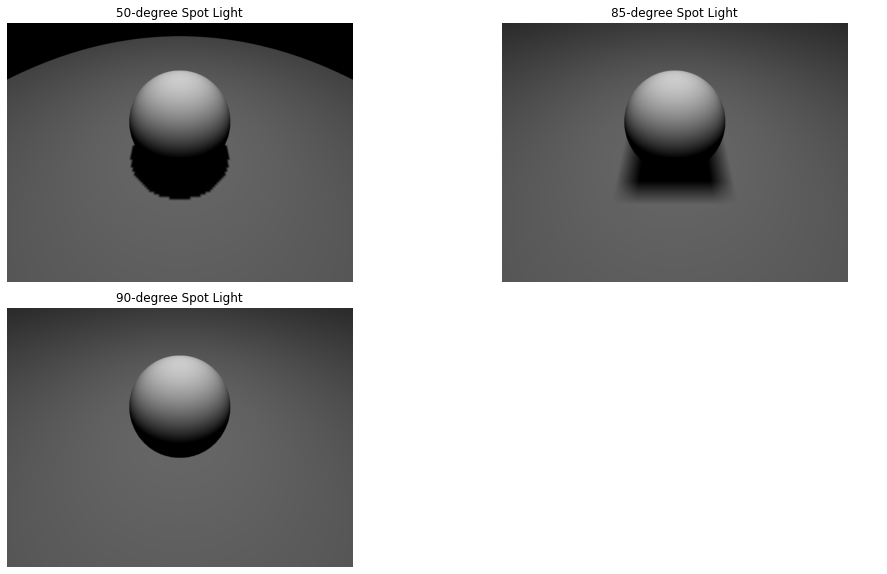

In [114]:
comparator.render()

We get a ball shadow for the 50- and 85-degree spot lights. The 90-degree spot
light casts no shadow.

The reason for this is related to `RenderEngineVtk`'s implementation. It is the
same reason the point light casts no shadows. The entire space visible to the
light is mapped to a single 2D image via a simple projection. If every possible
shadow a light can cast projects onto a single plane, then that light can
cast shadows. This is true for a spot light with `cone_angle < 90 degrees`. The
plane whose surface normal is parallel with the light's directional vector can
catch all of the shadows. But once the `cone_angle` value reaches 90-degrees,
there are emitted light rays that are *parallel* to that plane. They will
never intersect and therefore can't cast shadows onto the plane. In this case,
the implementation disables shadows entirely.

The second thing to note about the images is that the edges of the shadow
boundary between the 50-degree spot light and the 85-degree spot light are
obviously different. The shadow from the 85-degree spot light has been reduced
to a single, slightly blurry rectangle. This is a good time to get into shadow
map resolution.

#### Shadow map resolution

The shadow map is a rendering of the scene from the camera's perspective. Each
pixel stores the distance from camera to nearest surface. This makes it closely
resemble a depth map. The following illustration shows a simple scene with a
sphere and box being illuminated by a spot light.

<div style="text-align: center">
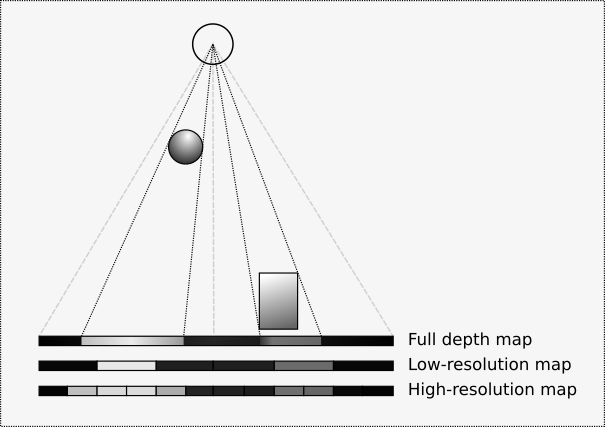
</div>

Below the scene are visualizations of the shadow map. The "Full depth map"
represents the idealized shadow map. In this case, we've colored "far" values as
black and "near" values as white. Note that although the sphere is smaller than
the box, because it is closer to the spot light, it has a larger footprint in
the shadow map. This idealized map doesn't have pixels, *per se*.

The next row down shows a coarse approximation of the idealized map. In this
case, the domain of the shadow map has been reduced to six pixels. The coarse
sampling leads to significant aliasing issues. The extents of the sphere and
box in the shadow map have changed significantly. It is easy to imagine that
for a 3D scene, the shadow of the sphere will be turned into a single square
pixel as observed above.

The final row doubles the resolution over the previous row. There are still
sampling artifacts, but the approximation of the actual shadow boundaries has
definitely improved.

Let's look at the `RenderEngineVtkParams::shadow_map_size` parameter and see
its impact on the shadows.

In [115]:
# Compare different levels of shadow resolution.

def make_config(custom_config):
    light = LightParameter(type="spot", frame="world",
                           position=[0, 0, 4], cone_angle=70,
                           direction=[0, 0, -1])
    return {"lights": [light], "cast_shadows": True} | custom_config

engine_params = [
    RenderEngineSpec("128 pixel map - spot", make_config({"shadow_map_size": 128})),
    RenderEngineSpec("256 pixel map - spot", make_config({"shadow_map_size": 256})),
    RenderEngineSpec("512 pixel map - spot", make_config({"shadow_map_size": 512})),
    RenderEngineSpec("1024 pixel map - spot", make_config({"shadow_map_size": 1024})),                     
]

comparator.set_render_engines(engine_params)

# Pick a view above the ground, but not straight down.
comparator.pose_camera_once(camera_in_world=[0, -2.5, 3.5])

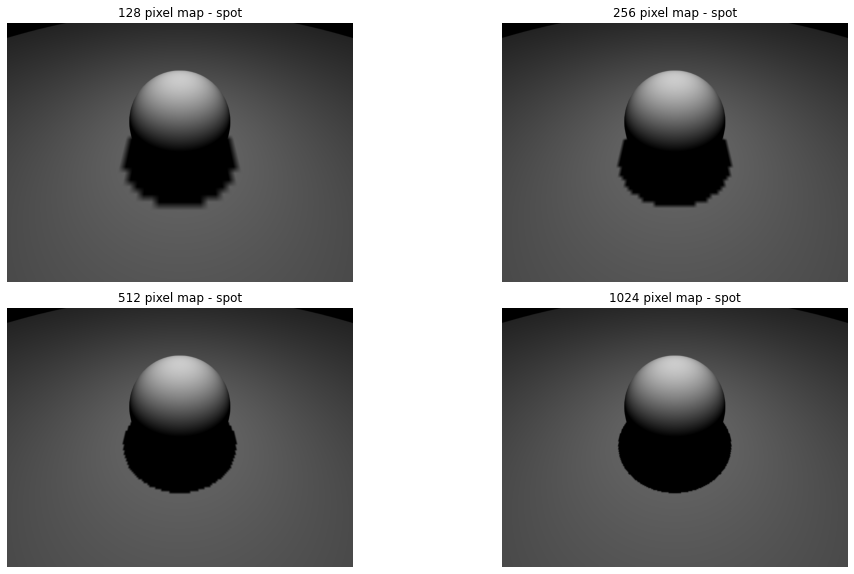

In [116]:
comparator.render()

For a fixed light, we can easily change the shadow map resolution to improve the
visual fidelity of the shadow edges. But this is a setting that needs to be used
judiciously. It would be "safe" to simply set all shadow maps to some large
(power-of-two) value to make sure that shadows all look clean. However, this
comes at a cost. Each shadow map must be re-rendered with each frame. The speed
of this depends on the rendering capability of your computer. It might be
reasonable to *try* setting shadow map resolution high straight across the board
and see if the performance is appreciably harmed. But, generally, the best
strategy is to use the lowest resolution map that provides a visually acceptable
shadow.

#### Shadow map registration

It is one thing to define the resolution of the image that stores the shadow
map. But what is the relationship of that image and the rendered world? In
other words, how big are those pixels? The bigger the pixels, the more likely
you are to notice the resolution.

The shadow map has to be "registered" to the world in some way -- defining which
portion of the world is accounted for by the shadow map. The image is
finite, the world is, in principle, infinite. So, only some *portion* of the
world can be included in the domain of the shadow map. There are no parameters
for controlling this domain of shadow coverage. So, how is it defined?

Both shadow-casting lights have their domains automatically and dynamically
computed on every rendering. At their core, each light determines the extent
of those objects that *can* be illuminated by the light, and registers the
shadow map to cover that full domain.

This domain is updated on a render-by-render basis to prevent objects moving in
and out of regimes in which shadows can be cast. However, it means if the extent
of the scene changes significantly from render to render, the shadows may
qualitatively change as well (e.g., previously smooth shadows become blocky).

Each shadow-casting light uses its own proprietary logic for determining the
illuminated domain.

##### Spot light

The spot light's illuminated domain is straightforward. The cone itself defines
the extent of what can be illuminated. As shown in the figure above, the shadow
map simply spans a bounding square of the cone's circular cross-section. It
does mean the corners of the shadow map are wasted (as objects that project
into the shadow map, but outside of the circle don't get illuminated anyways).

##### Directional light

Directional lights don't have finite extent. They can, in principle, cast light
anywhere in the world. In this case, the extent of the illuminated domain is
defined by the extent of the geometry that *can* be illuminated. Essentially, we
create a bounding *cube* around all of the geometry aligned to the directional
light. The size of the cube face is the size of the shadow map in the world.

This means the greater the reach of your geometry, the more shadow map resolution
you need for a directional light. This can come up easily when a ground plane
is added to the scene. Ultimately, the directional light's shadow map will be
stretched to cover the ground plane, even if the objects of interest span a
much smaller domain. To get good shadows on the objects of interest, large
shadow maps must be used.

It is quite common to create a scene, enable the shadows on a *directional*
light and see no shadows cast by or onto your target objects. It may simply be
that the shadow map has been stretched so large, that a shadow map pixel is
larger than your target objects; they simply don't render into the shadow map.

Let's see what that looks like.

In [117]:
# Compare different levels of shadow resolution.

def make_config(custom_config):
    light = LightParameter(type="directional", frame="world",
                           position=[0, 0, 4], cone_angle=70,
                           direction=[0, 0, -1])
    return {"lights": [light], "cast_shadows": True} | custom_config

engine_params = [
    RenderEngineSpec("64 pixel map - directional", make_config({"shadow_map_size": 64})),
    RenderEngineSpec("256 pixel map - directional", make_config({"shadow_map_size": 256})),
    RenderEngineSpec("1024 pixel map - directional", make_config({"shadow_map_size": 1024})),                     
]

comparator.set_render_engines(engine_params)

# Pick a view above the ground, but not straight down.
comparator.pose_camera_once(camera_in_world=[0, -1.5, 2.5])

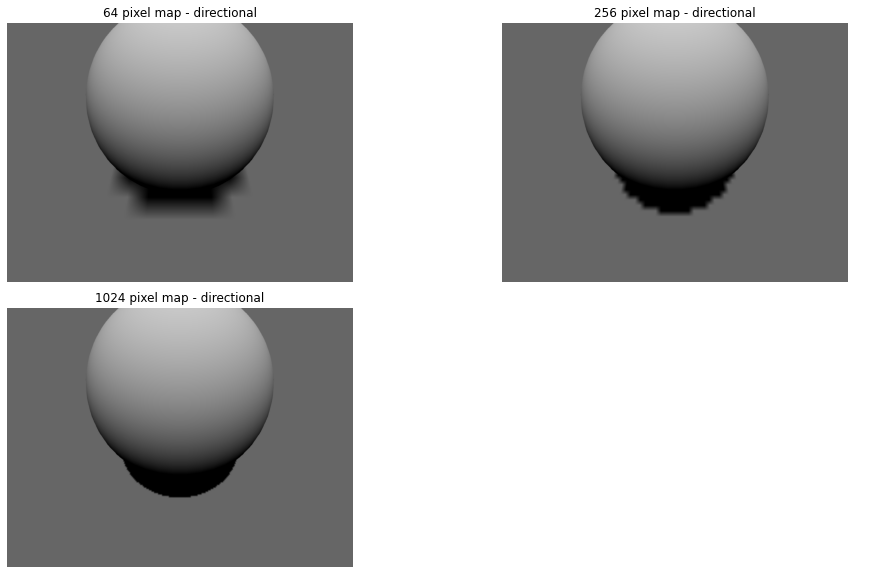

In [118]:
comparator.render()

Given that the light is emitting parallel light rays perpendicularly into the
ground, we would expect the ball's shadow to be the same size as the ball itself.
It is. Given the focal length of our render camera, we're getting strong
perspective effects -- things farther from the camera are scaled smaller than
things closer. When the ball is closer to the camera than its shadow, it will
appear larger. When the shadow is closer to the camera than the ball, the
shadow will appear bigger. THe important thing to note is that these shadows are
both expected and correct.

<a id="illumination-models"></a>
## Illumination Models (Phong vs PBR)

The illumination models are the mathematical models used to approximate light
and how those model get parameterized.

The <a href="https://en.wikipedia.org/wiki/Phong_reflection_model">Phong
illumination model</a> is a classic illumination model from the birth of
computer graphics. The fully-lit surface is rendered of the superposition of
three different lighting phenomena: diffuse, specular, and ambient light
sources. The model is phenomenological; it attempts to recreate observable
phenomenon but isn't derived from the underlying physics. This is the *default*
lighting model for `RenderEngineVtk`. The Phong lighting model tends to create
plastic-looking surfaces.

<a href="https://en.wikipedia.org/wiki/Physically_based_rendering">Physically
based rendering (PBR)</a> is a newer lighting model. As the name suggests, it
attempts to create illumination effects based on the underlying physics. It is
suitable for creating photorealistic images, even in real-time rendering
applications. It is the standard lighting model for all contemporary rendering
technology. `RenderEngineVtk` will implicitly change from Phong to PBR if:

- an environment map is added, or
- a glTF file is loaded. (glTF files area model representation that is
  explicitly designed to target PBR.)

`RenderEngineVtk` can also be explicitly configured to use PBR via the
`RenderEngineVtkParams.force_to_pbr` value.

Even if nothing else in the scene changes, switching from Phong to PBR will lead
to a qualitative change in the rendered image. Generally, the image will become
less bright and less saturated. The difference is that the the PBR model will
conserve energy (respect its "phyiscally-based" roots). The Phong model does not
conserve energy. Do not expect the light levels used in Phong-illuminated scene
to work in PBR-illuminated scenes. Generally, our recommendation is simply to
always use PBR-illuminated scenes to keep things simple. When in doubt, always
set `RenderEngineVtkParams.force_to_pbr` to `true`. (In the future, this may
simply become the default value.)

In [119]:
# Set up two, otherwise defaulted render engines.

comparator.set_render_engines([
    RenderEngineSpec("Phong", {}),
    RenderEngineSpec("PBR", {"force_to_pbr": True})
])

# Center on the ball, with it largely filling the frame.
comparator.pose_camera_once(camera_in_world=[0, -1.5, 2.5],
                            target_in_world=[0, 0, 1])

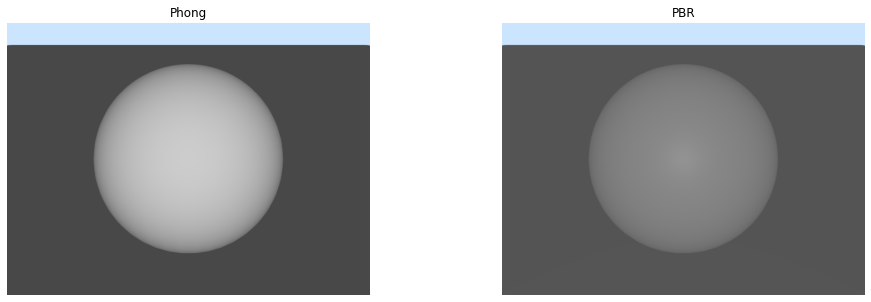

In [120]:
comparator.render()

These two renderings, while different, certainly don't suggest that PBR is a
clear improvement over Phong. This is because, the scene is too simple to
exploit the unique benefits of PBR.

Drake and `RenderEngineVtk` use the Phong model to a very limited degree. Many
parameters that would normally be part of the Phong model simply haven't been
exposed through the public API. So, configuring a primitive's materials will
always produce the dull appearance shown above. It is true that a Wavefront .obj
file can specify many Phong parameters in its related .mtl file, those materials will
still be filtered through Drake's limited Phong support. By default, these
Phong materials are used with the Phong illumination model. If the renderer
changes to use the PBR illumination model, Phong materials get automatically
converted to PBR materials.

As soon as we add a glTF file, `RenderEngineVtk` is *forced* to use the
PBR illumination model. Materials in glTF files are PBR materials and require
the PBR illumination model. In the following code, we'll introduce three spheres
(from a glTF file). We'll vary the "roughness" of the surface across the
spheres. A smooth surface is more mirror like, and we can clearly see the light
reflected in the surface. As roughness increases, the highlight becomes more
diffuse until, with full roughness (1.0), there is no specular highlight.

In [121]:
comparator = RenderComparator(meshcat)

# Add some geometry to the scene.
comparator.add_ground()
comparator.add_ball(pbr_material={"roughnessFactor": 0.1},
                    position=[-2.5, 0, 1])
comparator.add_ball(pbr_material={"roughnessFactor": 0.4},
                    position=[0, 0, 1])
comparator.add_ball(pbr_material={"roughnessFactor": 1.0},
                    position=[2.5, 0, 1])

# Make sure we push the geometry to the meshcat browser session.
comparator.visualize()

comparator.set_render_engines([
    RenderEngineSpec("Varying roughness", {}),
])

# Center on the ball, with it largely filling the frame.
comparator.pose_camera_once(camera_in_world=[0, -3.5, 3.5],
                            target_in_world=[0, 0, 1])

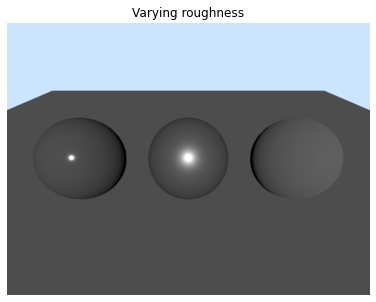

In [122]:
comparator.render()

This example shows very simple parameters. PBR materials have more properties
and those properties can be controlled with texture maps. This tutorial is not
about how to create such materials. Instead, we'll look into how we can
illuminate those surfaces.

TODO: I need a section on tips/tricks/warnings. Specifically, if roughness is
set to zero, there will be *no specular highlight* from lights on the surface.
This is because the radius of the specular dot goes to zero as rouhgness goes
to zero. So, it may be wise to make sure that materials never go to zero
roughness. A minimum value of 0.001 will allow specular light reflections to
appear on the surface. Further elaboration would reference *point* lights (e.g.,
point and spot). For directional lights, there will be one highlight per unique
direction (like an infinitely far point source).

*ATTENTION*: The rendered image typically deviates from what is shown in the meshcat
browser. From here on, the difference between the two renderings will only grow
greater. The illuminated appearance of objects in the meshcat browser are
outside the scope of this tutorial -- only use the visualizer to control camera
position for repeated renderings.

<a id="environment-maps"></a>
## Environment Maps

The name "environment map" probably invites an intuitive interpretation: a
painted backdrop. Rather than modeling an entire environment, we simply put an
image in the background which we can see directly and reflected in
mirror-like surfaces.

We'll start with a simple environment map and a mirror ball.

The image below shows a ball in a simple environment. The mirror ball sites on
a gray plane. Around it are four rectangular area lights. Blue and red lights
on either side, a white light above it and a distance smaller white light.

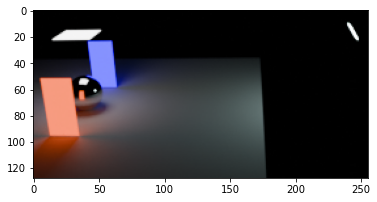

In [123]:
scene_path = FindResourceOrThrow("drake/tutorials/resources/env_color_room_in_situ.png")
scene_image = cv2.imread(scene_path)
plt.imshow(scene_image)

We can make an environment map by replacing the mirror ball with a panoramic
camera. The panoramic image encompasses all directions from the camera's
position. We can unwrap the sphere like a 
<a href="https://en.wikipedia.org/wiki/Mercator_projection">Mercator projection</a>
of the globe onto a map, with similar distortions.

The red and blue lights are clear to see in the image. The distant white light
is shown on the right of the blue light decreased in size due to its distance.
The top of the image is the single white area light above the camera. In a
Mercator projection, the north pole gets spread across the full width of the top
of the image. The light directly above the camera gets the same treatment.

This type of environment map is an "equirectangular map".

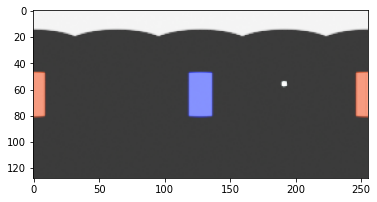

In [9]:
png_path = FindResourceOrThrow("drake/tutorials/resources/env_color_room.png")

png_env_map = cv2.imread(png_path)
plt.imshow(png_env_map)

# Also send the environment map to the meshcat session.
meshcat.SetEnvironmentMap(png_path)

The environment should also have appeared in your meshcat session. Rotate the
camera to see the various light panels. (The image is quite low resolution, so
the light panels should appear as blurry rectangles.) Ultimately, the full
effect of the environment map will be easier to understand when applied to a
scene.

In [10]:
comparator = RenderComparator(meshcat)

# Add some geometry to the scene.
comparator.add_ground()
# Make the ball as mirror-like as possible.
comparator.add_ball(pbr_material={"roughnessFactor": .5, "metallicFactor": 0})

# Make sure we push the geometry to the meshcat browser session.
comparator.visualize()

# Add a simple environment map.

comparator.set_render_engines([
    RenderEngineSpec("Mirror Ball",
                     {"environment_map": EnvironmentMap(
                        skybox=True,
                        texture=EquirectangularMap(path=png_path)),
                      # Disable the default light.
                      "lights": [LightParameter(intensity=0)]})])

# Center on the ball, with it largely filling the frame.
comparator.pose_camera_once(camera_in_world=[0, -2, 2],
                            target_in_world=[0, 0, 1])

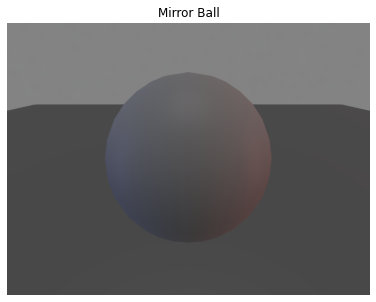

In [11]:
comparator.render()

The mirror ball reflects the environment map. As you rotate the meshcat viewer
camera and execute the previous code block again, you'll be able to see the
reflections of the light panel move across the surface.

Note: the lighting in meshcat will look slightly different than in the rendering
here. In addition to the environment map, meshcat has different lights than
were specified here.

In the PBR illumination model, the environment map is more than just a passive
image to be reflected in mirror surfaces. It is something to be reflected in
*all* surfaces. The environment is, in fact, a source of light. It supports both
*specular* (mirror-like) and *ambient* reflections.


### Specular light
Remember, the light that reaches a sensor (or eye) due to a *diffuse* reflection
only depends on the relative orientation of the surface normal and the light
rays that hit the surface. In contrast, a specular reflection depends on the
surface normal, the light ray, and the direction to the eye. In specular
reflections, the light ray simply gets reflected across the surface normal.
Examples of specular reflections include mirror-like reflections, and even shiny
spots observed on plastic (which themselves, are simply a reflection of the
light around the normal). So, a surface with a great deal of specular reflection
(typically smooth surfaces), will reflect the environment map as we've seen.

### Ambient light
When light is shined into a room, the light doesn't simply leave the light
source and strike a single surface before bouncing to your eye. The light
bounces many, many times. With each bounce the reflected light can change in
character. Light simply moves so fast that we can't observe this phenomenon; we
merely see the steady state of the light having bounced everywhere. This is the
reason why surfaces can be illuminated even if the light source can't shine
directly onto the surface; there is "indirect" lighting that does shine onto
the surface. This indirect lighting is called "ambient" light in graphics. The
environment map models that ambient light. It's a non-physical approximation of
a physical phenomenon. One important difference is that in the real world,
ambient light can be occluded just like direct light. In rendering, ambient
light is not subject to occlusion; every object in the scene gets illuminated
by the ambient light equally.

The previous rendering of the mirror ball illustrated the environment map's
effect on specular reflections. We can also observe its effect on ambient
reflections. We'll repeat the previous scene, but in addition to the mirror
ball, we'll also add a very rough sphere (which will have no specular
reflections). We'll still be able to observe the ambient light on the surface.

In [12]:
comparator = RenderComparator(meshcat)

# Add some geometry to the scene.
comparator.add_ground()

# Make the ball as mirror-like as possible.
comparator.add_ball(pbr_material={"roughnessFactor": 0, "metallicFactor": 1},
                   position=[-1.1, 0, 1])

# The ball is foam like -- as opposite the mirror ball as possible.
comparator.add_ball(pbr_material={"roughnessFactor": 1, "metallicFactor": 0},
                   position=[1.1, 0, 1])

# Make sure we push the geometry to the meshcat browser session.
comparator.visualize()

# Add a simple environment map.

comparator.set_render_engines([
    RenderEngineSpec("Environment Map - Specular vs Ambient",
                     {"environment_map": EnvironmentMap(
                        skybox=True,
                        texture=EquirectangularMap(path=png_path)),
                      # Disable the light; only ambient light in the scene.
                      "lights": [LightParameter(intensity=0)]})])

# Center on the ball, with it largely filling the frame.
comparator.pose_camera_once(camera_in_world=[0, -2.5, 2.5],
                            target_in_world=[0, 0, 1])

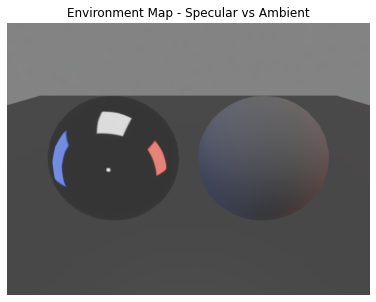

In [13]:
comparator.render()

Because of these two effects, environment maps impart a strong sense of objects
being embedded in the environment. The subtle ambient and not-so-subtle specular
reflections connect every surface in the scene to the environment. And as the
eye moves around the scene, the environment's illumination on the render targets
fools the human mind in all the right ways.

### High-Dynamic Range (HDR) Images

Not all images can serve as environment maps equally well. A typical image --
one typically seen online -- uses "normalized" color. That means the value for
each pixel is a value in the range [0, 1] (or [0, 255] depending on encoding).
This is good at communicating color information (hue, saturation, etc.) but it
has limited ability to communicate the full _dynamic_ range of radiant energy
possible. While physical light has varying frequency (signalling color in our
minds), it also has _intensity_. An ideal environment map is one that can encode
both color _and_ intensity. High-dynamic range (HDR) images use _unnormalized_
color data. They still communicate color properties (e.g., hue, saturation,
etc.), but they also encode intensity. The range between the dimmest and
brightest portions of the environment map can be arbitrarily large (as it is in
most human environments). We frequently don't notice because our eyes and brains
are good at taking a wide range of light levels and creating a coherent image
in a narrow range of energy levels. Cameras typically have a smaller dynamic
range than the human optical system, so photographers are always worrying about
shutter speed, film speed, and aperture to control how much light energy the
image medium is exposed to.

This is of critical importance when it comes to curating environment maps.
Environment maps encoded in normalized color images (e.g., png, jpg, bmp, etc.)
will have a different impact on the rendering than an unnormalized color image
(.hdr). In an environment map, a light intensity is associated with each
pixel. Light intensity can be characterized with various units. We'll use
watts (W) as being reasonably correlated with the _brightness_ of the light.
For a normalized image, _every_ pixel, regardless of color, has 1 W of energy;
there is no variation in intensity across the image, only color. To put that in
context, in real world scenarios, intensity can range multiple orders of magnitude
between the darkest and brightest light sources. That has two implications for
normalized color images:

  - The maximum (and, in fact, only) intensity of 1 W is quite dim compared to
    the real world.
  - They provide almost _no_ lighting contrast. What contrast exists usually
    comes from the _colors_ in the image and the general correlation with low
    intensity light sources manifesting as dark colors to film and sensors. As
    counter-intuitive as it might seem, a black pixel in a normalized color
    image is putting out 1 W of light, just like a white pixel. It's just 1 W
    of "black" light (but not in the "all-night rave" sense of the word).

The code below creates three renderings which differ in their environment maps.
The renderings are of the same abstract environment shown above and have the same
_color_ information. They differ in their maximum brightness.

  - PNG: a normalized image with brightness of 1 W at each pixel.
  - 125 HDR: an HDR image with maximum brightness of 125 W.
  - 500 HDR: an HDR image with maximum brightness of 500 W.

In [14]:
hdr125_path = FindResourceOrThrow("drake/tutorials/resources/env_color_room_125.hdr")
hdr500_path = FindResourceOrThrow("drake/tutorials/resources/env_color_room_500.hdr")
sky = FindResourceOrThrow("drake/tutorials/resources/white_sky_75.hdr")

def make_config(env_map_path):
    env_texture = EquirectangularMap(path=env_map_path)
    return {"environment_map": EnvironmentMap(
                                   skybox=True,
                                   texture=env_texture),
            # Disable the light; only ambient light in the scene.
            "lights": [LightParameter(intensity=0)]}

comparator.set_render_engines([
    RenderEngineSpec("Environment Map - 1-watt PNG", make_config(png_path)),
    RenderEngineSpec("Environment Map - 125-watt HDR", make_config(hdr125_path)),
    RenderEngineSpec("Environment Map - 500-watt HDR", make_config(hdr500_path)),
    RenderEngineSpec("Environment Map - 7.5-watt HDR", make_config(sky)),
    ])

# Center on the ball, with it largely filling the frame.
comparator.pose_camera_once(camera_in_world=[0, -2.5, 2.5],
                            target_in_world=[0, 0, 1])

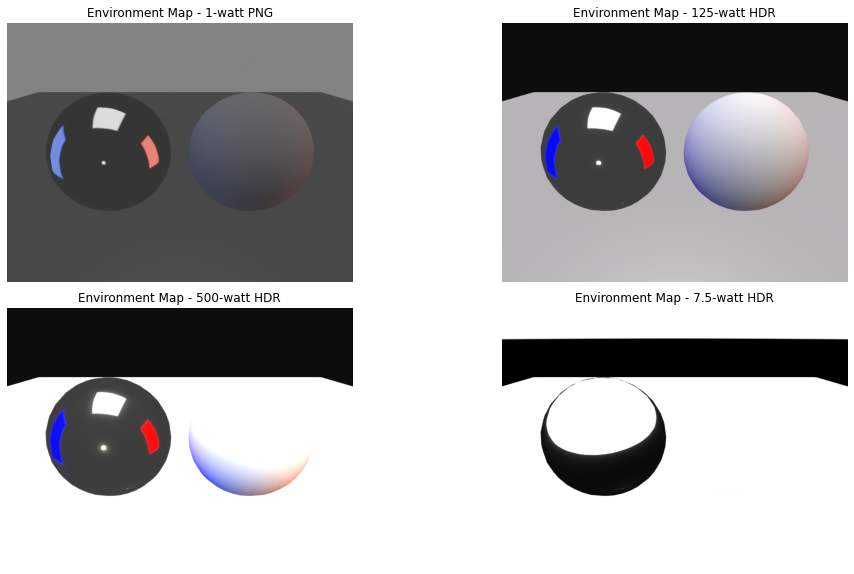

In [15]:
comparator.render()

Although the three images use environment maps with the exact same resolution
and the same *color* values at every pixel, the differences in pixel energy
produces significantly different results.

The 1-watt .png image is both dim and has low contrast (for the reasons
suggested above). The 125-watt image introduces a larger _range_ of
illumination across the pixels as well has having a greater maximum intensity.
Therefore, the image has greater contrast and more intense whites. The intensity
is so high with the 500-watt image that the illuminated portions of the
image have become over saturated and details have been washed out.

Does this mean that we need to make sure our HDR environment maps have energy
levels within a certain range to prevent image over saturation? No.

<a id="tone-mapping"></a>
#### Tone mapping and exposure

We need to take a brief detour to understand how high dynamic range images get
drawn to your screen (and saved as normalized color maps).

In the images above, the image using the 1-watt .png image has 1/500th the light
energy as the image rendered with the 500-watt environment map. And yet, the
"dim" image is not simply a copy of the bright image with each pixel having
1/500th the value of the original (in fact, given 8-bit color, that would
simply be a black image). So, what's happening?

The answer is "tone mapping". It's the process by which an image with
"unbounded" intensity levels gets mapped to an image (or display) with
normalized color. As hinted to above, the mapping is _not_ strictly linear.
Generally, near the darkest and brightest features, there is non-linear
tapering in attempt to preserve details at the extremes of illumination.

In fact, there are various mapping functions. 
`RenderEngineVtk` (the only `RenderEngine` used in this tutorial) uses the
<a href="https://www.kitware.com/pbrj1/">"Generic Filmic tone mapping
operator</a>. There are multiple parameters associated with that operator.
To keep things simple, Drake exposes a single parameter: `exposure`.
If you are familiar with photography, the rendering idea of exposure is
analogous to the photographic term. It essentially is a way to control how much
the "film" is exposed to the the scene's radiant energy. Expose it less and the
final image is darker. Expose it more, and the image is brighter. Go too far
in either direction, and the final image can either be a dark mess or a washed
out blur of whiteness. More precisely, `exposure` is simply a scale factor
applied to the image prior to performing the mapping. So, if a pixel in the
resulting image is reflecting 10 W to the camera, an `exposure` value of 0.5
will mean we map a 5-watt intensity at that pixel. The default value for
`exposure` is 1. Values below one will pull the brightest pixels away from
white (and possible over saturation). Values above one will push the dimmest
pixels away from black. Values greater than one will have the effect of lowering
contrast as every pixels gets pushed towards white.

It's clear in the above image that the image using the 1-watt .png image is
underexposed (the diffuse ball is too dark). At the same time, the image using
the 500-watt .hdr image is overexposed (the grey sphere is almost a white
silhouette). Let's render the images again, but this time tune the exposure.

In [16]:
def make_config(env_map_path, exposure):
    env_texture = EquirectangularMap(path=env_map_path)
    return {"environment_map": EnvironmentMap(
                                   skybox=True,
                                   texture=env_texture),
            "exposure": exposure,
            # Disable the light; only ambient light in the scene.
            "lights": [LightParameter(intensity=0)]}

comparator.set_render_engines([
    RenderEngineSpec("Increased Exposure - 1-watt PNG", make_config(png_path, 5)),
    RenderEngineSpec("Default Exposure - 125-watt HDR", make_config(hdr125_path, 1.0)),
    RenderEngineSpec("Decrease Exposure - 500-watt HDR", make_config(hdr500_path, 0.25)),
    RenderEngineSpec("Decrease Exposure - 7.5-watt HDR", make_config(sky, 0.125)),
    ])

# Center on the ball, with it largely filling the frame.
comparator.pose_camera_once(camera_in_world=[0, -2.5, 2.5],
                            target_in_world=[0, 0, 1])

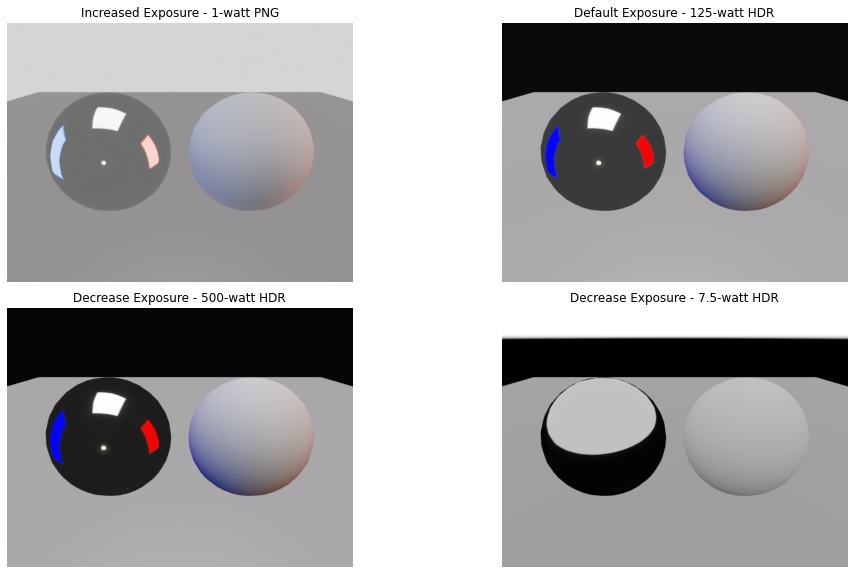

In [17]:
comparator.render()

We can see the effect of exposure on the three images.

The diffuse ball in the 1-watt image is now much brighter (comparable to the
ball in the 125-watt image). However, the contrast is worse than before; there
are _no_ black pixels.

The diffuse ball in the 500-watt image has been pulled back to the same grey as
the 125-watt image. It is no longer over saturated and the curvature of the ball
can easily be seen. Note that the black in the mirror ball is _darker_ than the
mirror ball in the 125-watt image. This is because the 500-watt image has a
larger range, so the color of the ball, reflecting the background, gets pushed
closer to the low-end of the mapping function's domain, increasing the contrast.

Judicious use of exposure is critical in producing images that are both
aesthetically pleasing as well as modeling sensors that automatically adjust
their own exposure automatically.

#### Where do you get environment maps?

The two easiest ways to get environment maps are from open source web
repositories like [Polyhaven](https://polyhaven.com/).

The simple environment map used in this tutorial were created in Blender.
There are copious tutorials on Youtube on how to do this, like
[this one](https://www.youtube.com/watch?v=6YMlMEXsiYU)

<a id="total-illumination"></a>
## Total Illumination

Environment maps can't cast shadows. Direct lights can. A fully-lit scene
will include *both*.

However, it is easy to add an environment map and a shadow-casting light and
see no shadows. This typically arises if there is a significant difference
between the energy levels of the shadow-casting and the environment map.

To get shadows _and_ the benefit of the environment map, it is neccessary to
scale the light intensity with the environment. (Imagine trying to use a
flashlight to cast shadows outdoors on a sunny day.)

However, once the lights have been scaled appropriately with respect to the
environment the _total_ amount of illumination may be too much and the
exposure will need to be reduced to avoid over saturation.

possible examples
  - Just lights with various intensities and exposure
  - Dim light in bright environment
  - Bright light in dim environment

The following example shows the effect of .... stuff.

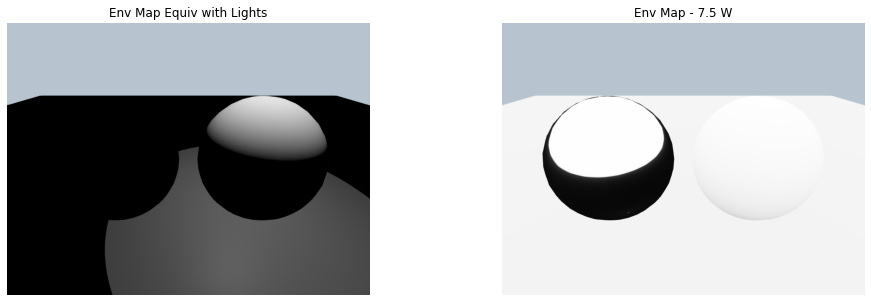

In [34]:
def make_light(custom_params = {}):    
    return LightParameter(**({"type": "spot",
                              "frame": "world",
                              "cone_angle": 40,
                              "position": [1.1, 0, 3],
                              "direction": [0, 0, -1],
                              "intensity": 7.5,
                              # Why do I need this attenuation to get an
                              # equivalent result?
                              "attenuation_values": [0, 0.0, 1.0],
                              } | custom_params)) 

def make_config(lights, exposure):
    return {"exposure": exposure,
            "cast_shadows": False,
            "lights": lights}

comparator.set_render_engines([
    RenderEngineSpec("Env Map Equiv with Lights", make_config([make_light({"intensity": 7.5}),
#                                                   make_light({"position": [3.5, 0, 1.57],
#                                                               "direction": [-1, 0, 0],
#                                                               "intensity": 3.75,
#                                                               "color": Rgba(1, 0, 0)}),
#                                                   make_light({"position": [-3.5, 0, 1.57],
#                                                               "direction": [1, 0, 0],
#                                                               "intensity": 3.75,
#                                                               "color": Rgba(0, 0, 1)}),
#                                                   make_light({"position": [0, -15, 4.4],
#                                                               "direction": [0, .97, .25],
#                                                               "intensity": 125,
#                                                               "color": Rgba(1, 1, 1)}),
                                                  ], 1)),
     RenderEngineSpec("Env Map - 7.5 W",
                      {"exposure": 1,
                       "environment_map": EnvironmentMap(
                           skybox=False, texture=EquirectangularMap(path=sky)),
                       # Disable the light; only ambient light in the scene.
                       "lights": [LightParameter(intensity=0)]})
    ])

# Center on the ball, with it largely filling the frame.
comparator.pose_camera_once(camera_in_world=[0, -2.5, 2.5],
                            target_in_world=[0, 0, 1])

comparator.render()

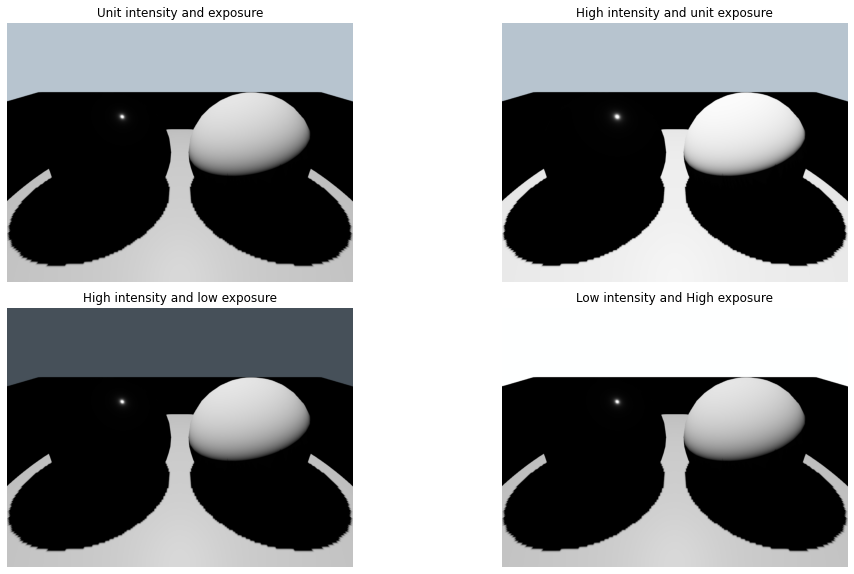

In [80]:
def make_config(intensity, exposure):
    light = LightParameter(type="spot", frame="world",
                           position=[0, 0, 4], cone_angle=40,
                           direction=[0, 0, -1],
                           intensity=intensity)
    return {"exposure": exposure,
            "cast_shadows": True,
            "lights": [light]}

comparator.set_render_engines([
    # The light square in the 125-watt environment map is 7.5 W. By placing
    # single shadow-casting light *above* the spheres with the same intensity,
    # we'll reproduce the lighting on the sphere top.
    RenderEngineSpec("Unit intensity and exposure", make_config(7.5, 1)),
    RenderEngineSpec("High intensity and unit exposure", make_config(20, 1)),
    RenderEngineSpec("High intensity and low exposure", make_config(75, 0.1)),
    RenderEngineSpec("Low intensity and High exposure", make_config(0.75, 10)),
    ])

# Center on the ball, with it largely filling the frame.
comparator.pose_camera_once(camera_in_world=[0, -2.5, 2.5],
                            target_in_world=[0, 0, 1])

comparator.render()

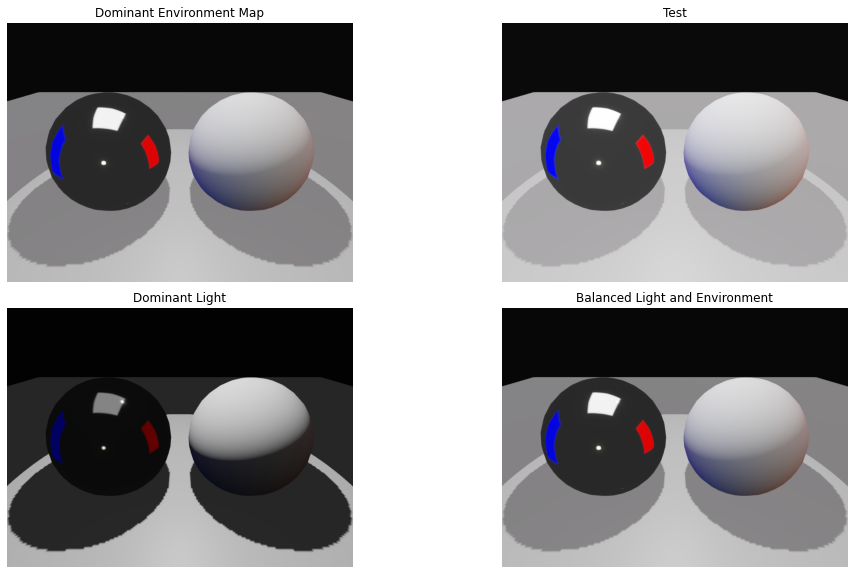

In [81]:
def make_config(env_map_path, intensity, exposure):
    env_texture = EquirectangularMap(path=env_map_path)
    light = LightParameter(type="spot", frame="world",
                           position=[0, 0, 4], cone_angle=40,
                           direction=[0, 0, -1],
                           intensity=intensity)
    return {"environment_map": EnvironmentMap(
                                   skybox=True,
                                   texture=env_texture),
            "exposure": exposure,
            "cast_shadows": True,
            # Disable the light; only ambient light in the scene.
            "lights": [light]}

comparator.set_render_engines([
    RenderEngineSpec("Dominant Environment Map", make_config(hdr125_path, 7.5, 0.5)),
    RenderEngineSpec("Test", make_config(hdr125_path, 4, 1)),
    RenderEngineSpec("Dominant Light", make_config(hdr125_path, 125, 0.04)),
    RenderEngineSpec("Balanced Light and Environment", make_config(hdr125_path, 8, 0.5)),
    ])

# Center on the ball, with it largely filling the frame.
comparator.pose_camera_once(camera_in_world=[0, -2.5, 2.5],
                            target_in_world=[0, 0, 1])

comparator.render()

What happened? Why don't the shadows work? The reason for this is that the
environment map injects far more luminance energy into the scene than the
direct light does. In order for them to work together, they must be balanced
appropriately.

  - Light intensity
  - Exposure

Given an environment map and some reference light intensities, how do we scale
the light intensities to accommodate the light? And then what do we do with the
exposure?

In [82]:
# Set up two, otherwise defaulted render engines.

hdr_path = FindResourceOrThrow(
    "drake/geometry/test/env_256_six_color_room.hdr")
hdr_path = FindResourceOrThrow("drake/tutorials/resources/env_color_room_125.hdr")
png_path = FindResourceOrThrow("drake/tutorials/resources/env_color_room.png")

light_params = {
    "type": "spot",
    "direction": np.array((-1, 0, -1)),
    "position": [4, 0, 4],
    "cone_angle": 35,
}

light = LightParameter(type="spot",
                       frame="world",
                       # Note: the direction vector doesn't have to
                       # be unit length.
                       direction=np.array((-1, 0, -1)),
                       position=[4, 0, 4],
                       cone_angle=35,
                       intensity=3.5)
exposure = 0.1
comparator.set_render_engines([
    RenderEngineSpec("HDR Environment Map", {"environment_map": EnvironmentMap(skybox=True, texture=EquirectangularMap(path=hdr_path)),
                                             "lights": [LightParameter(**(light_params | {"intensity": 3.5}))],
                                             "cast_shadows": True,
                                             "exposure": 0.15}),
    RenderEngineSpec("PNG Environment Map", {"environment_map": EnvironmentMap(skybox=True, texture=EquirectangularMap(path=png_path)),
                                             "lights": [LightParameter(**light_params)],
                                             "cast_shadows": True,
                                             "exposure": 1}),
    RenderEngineSpec("No Environment Map", {"lights": [light], "force_to_pbr": True})
])

# Center on the ball, with it largely filling the frame.
comparator.pose_camera_once(camera_in_world=[0, -3.0, 4.0],
                            target_in_world=[0, 0, 1])

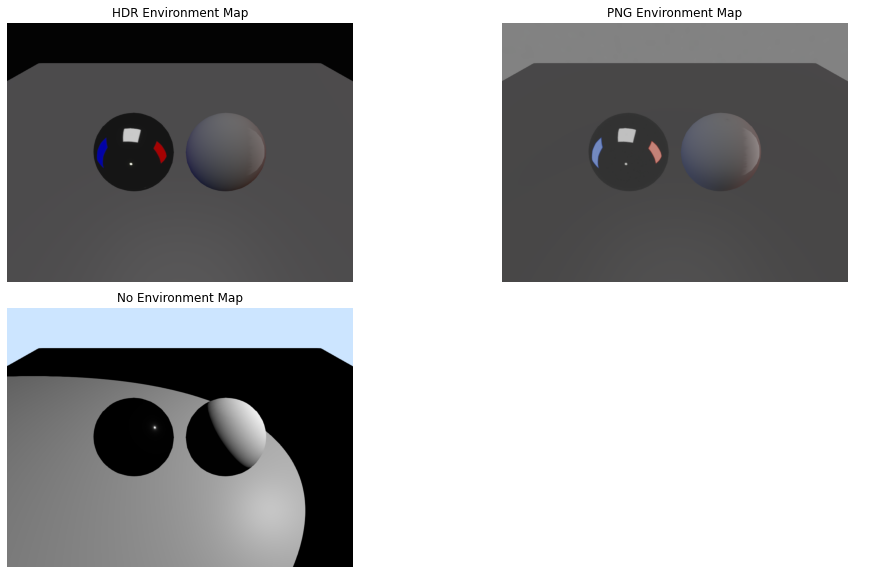

In [83]:
comparator.render()

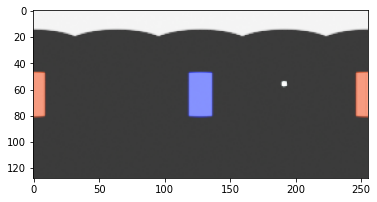

In [84]:
import cv2
png_env_map = cv2.imread(png_path)
plt.imshow(png_env_map)
meshcat.SetEnvironmentMap(png_path)

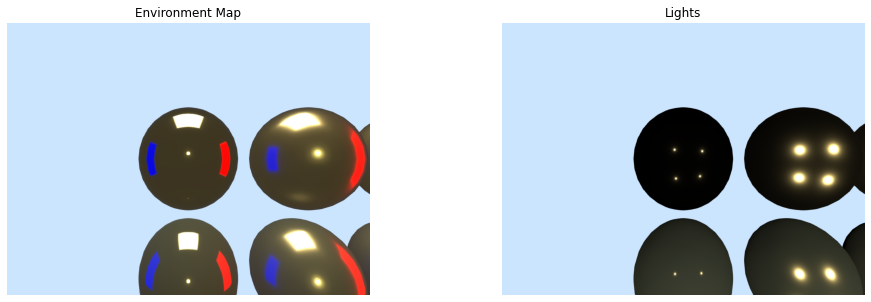

In [89]:
# Experiment to see how much PBR interacts with lighting as documented in
# https://learnopengl.com/PBR/Lighting
hdr125_path = FindResourceOrThrow("drake/tutorials/resources/env_color_room_125.hdr")

comparator = RenderComparator(meshcat)

N = 7
values = np.linspace(0.01, 1.0, N)

for z, metallic in enumerate(values):
    for x, roughness in enumerate(values):
        comparator.add_ball(
            pbr_material={
                "roughnessFactor": roughness,
                "metallicFactor": metallic,
                "baseColorFactor": [0.8, 0.6, 0.2, 1]},
            position=[2.2 * x, 0, 2.2 * z])

comparator.visualize()

# Add a simple environment map.

l = {"type": "point", "frame": "world", "intensity": 1}
d = 15
y = 25
c = 2.2 * (N - 1) * 0.5
comparator.set_render_engines([
    RenderEngineSpec("Environment Map",
                     {"environment_map": EnvironmentMap(
                        skybox=False,
                        texture=EquirectangularMap(path=hdr125_path)),
                      # Disable the light; only ambient light in the scene.
                      "lights": [LightParameter(intensity=0)]}),
    RenderEngineSpec("Lights",
                     {"lights": [
                         LightParameter(**(l | {"position": [c - d, -y, c + d]})),
                         LightParameter(**(l | {"position": [c - d, -y, c - d]})),
                         LightParameter(**(l | {"position": [c + d, -y, c + d]})),
                         LightParameter(**(l | {"position": [c + d, -y, c - d]})),
                     ]})
])

# Center on the ball, with it largely filling the frame.
comparator.pose_camera_once(camera_in_world=[c, -10.5, c],
                            target_in_world=[c, 2.5, c])
comparator.pose_camera_once(camera_in_world=[0, -3.5, 2 * c],
                            target_in_world=[0, 2.5, 2 * c])

comparator.render()

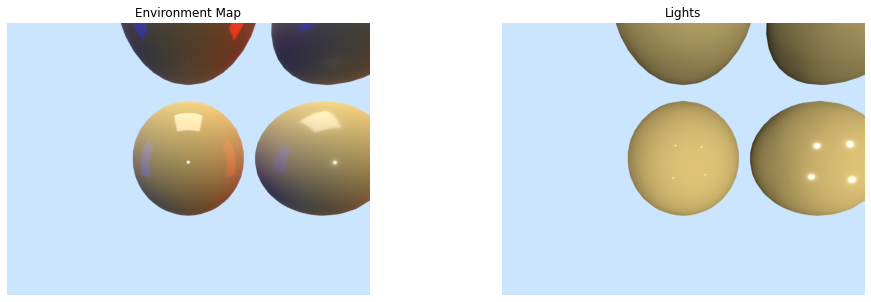

In [88]:
comparator.render()